In [1]:
import matplotlib.pyplot as plt

In [2]:
seats = []
rows = ["A", "B", "C", "D", "E"]

for i, row in enumerate(rows, start=1):   # row index 1–5
    for col in range(1, 6):               # col index 1–5
        # Giá theo hàng 
        if row in ["A"]: 
            seat_type = 2   # Sweetbox
            price = 200000
        elif row in ["E"]:
            seat_type = 1   # VIP
            price = 150000
        else:
            seat_type = 0   # Normal
            price = 100000 
        
        # Vị trí theo cột
        if col == 3:
            position = 1  # center
        elif col in [1, 2]:
            position = 3  # edge
        else:
            position = 2  # far
        
        # Trạng thái: mặc định trống 
        status = 0
        seats.append([i, col, seat_type, position, status, price])


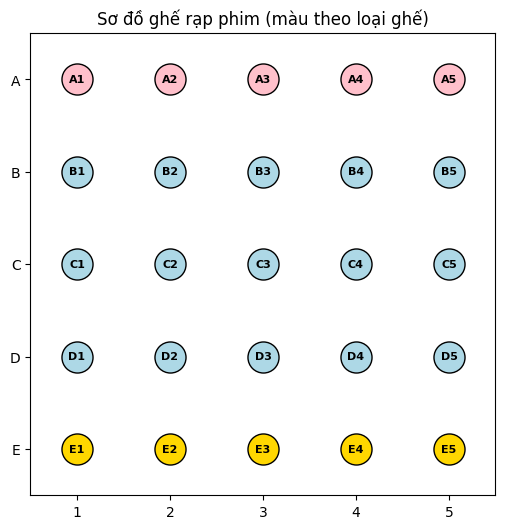

In [3]:

# Vẽ sơ đồ ghế
fig, ax = plt.subplots(figsize=(6, 6))
colors = {0: "lightblue", 1: "gold", 2: "pink"}  # Normal, VIP, Sweetbox

for seat in seats:
    row, col, seat_type, position, status, price = seat
    ax.scatter(col, 6-row, 
               c=colors[seat_type], 
               s=500, edgecolors="black")
    ax.text(col, 6-row, f"{rows[row-1]}{col}", 
            ha="center", va="center", fontsize=8, weight="bold")

ax.set_xlim(0.5, 5.5)
ax.set_ylim(0.5, 5.5)
ax.set_xticks(range(1, 6))
ax.set_yticks(range(1, 6))
ax.set_yticklabels(rows[::-1])  # Show A at bottom, E at top
ax.set_title("Sơ đồ ghế rạp phim (màu theo loại ghế)")
ax.grid(False)
plt.show()


In [4]:

# Hàm tìm ghế
def find_seats(data_seats, type_wanted, pos_wanted, 
               status_wanted, price_limit):
    results = []
    for seat in data_seats:
        row, col, seat_type, position, status, price = seat
        if (seat_type == type_wanted 
            and position == pos_wanted 
            and status == status_wanted 
            and price <= price_limit):
            results.append(seat)
    return results

In [5]:
# Input yêu cầu (ví dụ: tìm VIP, center, available, giá <=150000)
results = find_seats(
    data_seats=seats,
    type_wanted=0,      # Normal
    pos_wanted=1,       # center
    status_wanted=0,    # available
    price_limit=150000
)

In [6]:
# In kết quả
for r in results:
    row, col, seat_type, position, status, price = r
    print(f"Hàng {rows[row-1]}, Cột {col} thỏa mãn yêu cầu (Giá: {price})")


Hàng B, Cột 3 thỏa mãn yêu cầu (Giá: 100000)
Hàng C, Cột 3 thỏa mãn yêu cầu (Giá: 100000)
Hàng D, Cột 3 thỏa mãn yêu cầu (Giá: 100000)
